# API Testing

This notebook demonstrates how to call the FastAPI endpoints in notebook.

In [1]:
import sys
from pathlib import Path

# Add the project root directory to sys.path
root_dir = Path.cwd().resolve().parents[0]  # Adjust parent index if needed
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fastapi.testclient import TestClient
from modeling.api.app import app

import modeling.config as C

/Users/abdulkodir/Downloads/MLOps Finpro/.venv/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


In [2]:
df_sampled = pd.read_csv('../dataset/chicago_risk_pseudo_labels-2.csv')
df_risk_scores = pd.read_csv('../dataset/sampled_dataset_engineered.csv')

## 1. Check API Health and Available Models

In [3]:
with TestClient(app) as client:
    models_resp = client.get('/models')
    print('\nAvailable Models:')
    for m in models_resp.json()['models']:
        print(f"- {m['name']} (Active: {m['active_version']})")

[routes] cache ready: 317,815 graph nodes, 100,876 crime records

Available Models:
- baseline (Active: -)
- LinearRegression (Active: v8)
- DecisionTreeRegressor (Active: v8)
- RandomForestRegressor (Active: v6)
- XGBRegressor (Active: v6)


## 2. Get Risk Score of an Input

In [7]:
with TestClient(app) as client:
	lat, lon = 41.8781, -87.6298
	datetime_str = '2026-08-01T12:00:00'
	model: C.MODEL_NAMES = "baseline"

	data = client.get(f'/risk-score?lat={lat}&lon={lon}&datetime={datetime_str}&model={model}')
	response = data.json()
 
	display(response)

[startup] walk graph loaded (DiGraph)
[routes] loaded crime records: 100876


{'risk_score': 1.0,
 'level': 'Low',
 'model_used': 'baseline',
 'model_version': '-',
 'last_updated': '2026-08-07',
 'disclaimer': 'Estimate based on historical patterns, not a prediction of certainty.'}

## 3. Get all Models & compariosn
We query the `/risk-score/compare` endpoint for a specific location and time.

In [8]:
with TestClient(app) as client:
	lat, lon = 41.8781, -87.6298
	datetime_str = '2026-08-01T12:00:00'

	compare_resp = client.get(f'/risk-score/compare?lat={lat}&lon={lon}&datetime={datetime_str}')
	compare_data = compare_resp.json()

	results_df = pd.DataFrame(compare_data['estimates'])
	display(results_df)

[startup] walk graph loaded (DiGraph)
[routes] loaded crime records: 100876


,model_used,model_version,risk_score,level
0,baseline,-,1.00,Low
1,LinearRegression,v8,0.00,Low
2,DecisionTreeRegressor,v8,1.07,Low
3,RandomForestRegressor,v6,1.00,Low
4,XGBRegressor,v6,1.38,Low


/var/folders/_m/x30w5wkd6l59g090_2t6sv1w0000gn/T/ipykernel_33554/119773760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_used', y='risk_score', data=results_df, palette='viridis')


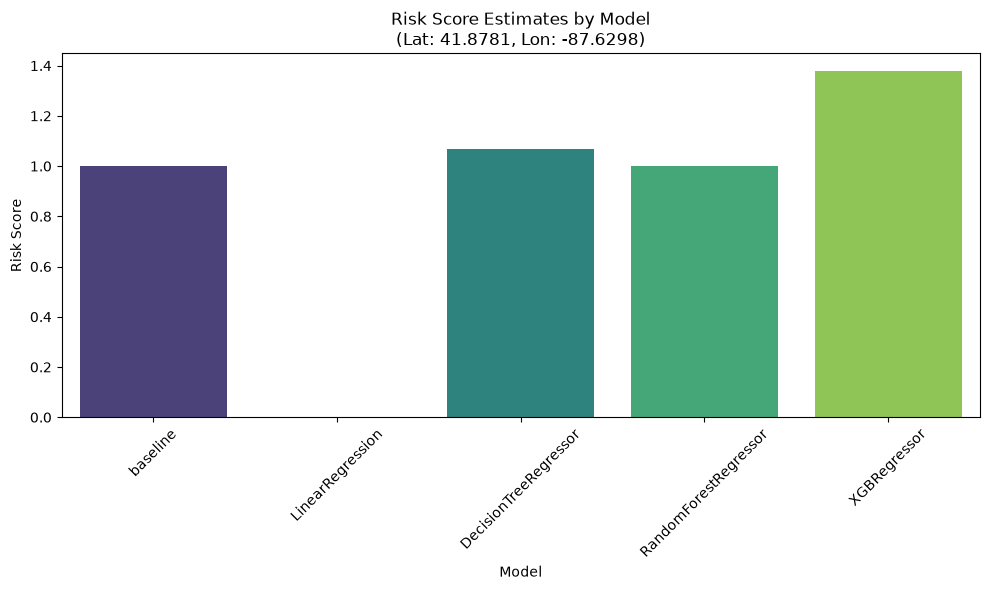

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x='model_used', y='risk_score', data=results_df, palette='viridis')
plt.title(f'Risk Score Estimates by Model\n(Lat: {lat}, Lon: {lon})')
plt.ylabel('Risk Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Get Models History
We query the `/models/{model_name}/history`.

In [10]:
with TestClient(app) as client:
	model: C.MODEL_NAMES = 'LinearRegression'

	model_history = client.get(f'/models/{model}/history')
	response = model_history.json()

	display(response)

[startup] walk graph loaded (DiGraph)
[routes] loaded crime records: 100876


{'model_name': 'LinearRegression',
 'active_version': 'v8',
 'versions': [{'version': 'v2',
   'saved_at': '2026-08-02T19:43:58',
   'metrics': {'train': {'MAE': 2.1016130587945034,
     'RMSE': 2.79835176432674,
     'R2': 0.9521757513488756},
    'val': {'MAE': 1.6425719795142004,
     'RMSE': 2.2321779021700423,
     'R2': 0.9420348743484643},
    'test': {'MAE': 1.6019441554502292,
     'RMSE': 2.1313202466628316,
     'R2': 0.9329859140424823}},
   'improvement_vs_baseline': {'val': {'MAE_pct': 32.70290988079874,
     'RMSE_pct': 27.180437733105883,
     'R2_delta': 0.051347582469252084},
    'test': {'MAE_pct': 29.693584752853468,
     'RMSE_pct': 24.864722922334725,
     'R2_delta': 0.051693456411584515}}},
  {'version': 'v3',
   'saved_at': '2026-08-02T19:58:29',
   'metrics': {'train': {'MAE': 2.10037929933465,
     'RMSE': 2.80171033027738,
     'R2': 0.9518968258133652},
    'val': {'MAE': 1.6499171356907851,
     'RMSE': 2.2405093367193873,
     'R2': 0.9424932843000889},
 

all versions can be looked here

## 5. Get Recent Logs
We query the `/logs/recent`.

In [11]:
with TestClient(app) as client:

	logs = client.get(f'/logs/recent')
	response = logs.json()

	display(response)

[startup] walk graph loaded (DiGraph)
[routes] loaded crime records: 100876


{'total': 12,
 'returned': 12,
 'logs': [{'ts': '2026-08-07T19:07:32',
   'lat': 41.8781,
   'lon': -87.6298,
   'model': 'baseline',
   'version': None,
   'risk_score': 1.0,
   'level': 'Low',
   'latency_ms': 80.75},
  {'ts': '2026-08-06T21:53:27',
   'lat': 41.8781,
   'lon': -87.6298,
   'model': 'baseline',
   'version': None,
   'risk_score': 1.0,
   'level': 'Low',
   'latency_ms': 102.52},
  {'ts': '2026-08-06T21:07:53',
   'lat': 41.8781,
   'lon': -87.6298,
   'model': 'baseline',
   'version': None,
   'risk_score': 1.0,
   'level': 'Low',
   'latency_ms': 94.66},
  {'ts': '2026-08-05T21:43:45',
   'lat': 41.8781,
   'lon': -87.6298,
   'model': 'baseline',
   'version': None,
   'risk_score': 1.0,
   'level': 'Low',
   'latency_ms': 55.96},
  {'ts': '2026-08-05T21:31:23',
   'lat': 41.8781,
   'lon': -87.6298,
   'model': 'baseline',
   'version': None,
   'risk_score': 1.0,
   'level': 'Low',
   'latency_ms': 88.6},
  {'ts': '2026-08-02T22:40:43',
   'lat': 41.8781,
   'l

## 6. Get Safest Route V1
We query the `/route/v1`.

In [4]:
with TestClient(app) as client:
	lat1, lon1 = df_sampled['Latitude'].iloc[20], df_sampled['Longitude'].iloc[20] 
	lat2, lon2 = df_sampled['Latitude'].iloc[35], df_sampled['Longitude'].iloc[35] 
	datetime_str = pd.Timestamp("2026-07-27 21:00:00")  # 9pm — worth testing at a "riskier" hour

	params = {
		"lat1": lat1, "lon1": lon1,
		"lat2": lat2, "lon2": lon2,
		"datetime": datetime_str,
		"k": 3
	}

	response = client.get('/route/v1', params=params)

	assert response.status_code == 200, f"API Failed: {response.text}"
	display(response.json())

[routes] cache ready: 317,815 graph nodes, 100,876 crime records
Route 0: 1 unique intersection points, cost=0.0m
  -> densified to 1 points (every ~300m along the actual walk path)


{'route': [{'lat': 41.8785869, 'lon': -87.7458383}],
 'risk_score_mean': 66.6,
 'risk_score_max': 66.6,
 'disclaimer': 'Estimate based on historical patterns, not a prediction of certainty.'}

## 6. Get Safest Route V2
We query the `/route/v2`.

In [6]:
with TestClient(app) as client:
	lat1, lon1 = df_sampled['Latitude'].iloc[10], df_sampled['Longitude'].iloc[10] 
	lat2, lon2 = df_sampled['Latitude'].iloc[25], df_sampled['Longitude'].iloc[25] 
	datetime_str = pd.Timestamp("2026-07-27 21:00:00")  # 9pm — worth testing at a "riskier" hour

	params = {
		"lat1": lat1, "lon1": lon1,
		"lat2": lat2, "lon2": lon2,
		"datetime": datetime_str,
		"k": 3
	}

	response = client.get('/route/v2', params=params)

	assert response.status_code == 200, f"API Failed: {response.text}"
	display(response.json())

[routes] cache ready: 317,815 graph nodes, 100,876 crime records
Route 0: 1 unique intersection points, cost=0.0m
  -> densified to 1 points (every ~50m along the actual walk path)


{'route': [{'lat': 41.8785869, 'lon': -87.7458383}],
 'risk_score_mean': 66.6,
 'risk_score_max': 66.6,
 'disclaimer': 'Estimate based on historical patterns, not a prediction of certainty.'}